# Integration (alignment) of clonal embeddings

To perform an analysis of multiple cohorts, there might be multiple approaches:
1. you can build an integrated gene expression embedding that includes all cohorts of your interest, or
2. you can build clonal embeddings for each dataset and integrate them.

The first approach can be relatively hard as soon as creation of integrated embeddings of cells from very different context is challenging. We decided to suggest an option for the second path with newly introduced procedure of clonal embeddings integration.

In this notebook, we're going to check how this procedure work and compare results of the first and the second strategy using Weinreb et al. in vitro hematopoiesis dataset.

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import clone2vec as c2v

sc.set_figure_params(dpi=80)
sc.settings.verbosity = 3
sns.set_style("ticks")

In [2]:
adata = c2v.datasets.Weinreb_in_vitro(embedding_type="gex")

using gene expression embedding


## Building a ground truth clonal embedding

In this dataset, we already have multiple timepoints integrated together. We will take only cells collected at the day 4 (atch 1 will contain cells from the first well, batch 2 will contain cells from the second well).

In [3]:
adata_d4 = adata[(adata.obs["Time point"] == 4)].copy()
clones_d4 = c2v.pp.clones_adata(adata_d4, obs_name="time:well:clone")

creating clone-level AnnData
    selected 1943 clones (>= 3)
    finished (0:00:00): created clones AnnData with
     .X float matrix of proportions (clones × categories)
     .layers['proportions'] float matrix with fate proportions
     .layers['counts'] integer matrix with fate counts
     .obs['n_cells'] integer vector with number of cells per clone
     .obs['n_fates'] integer vector with number of fates per clone
     .var['n_clones'] integer vector with number of clones per fate
     .uns['fill_obs'] string label


In [4]:
c2v.tl.clonal_nn(adata_d4, clones_d4, use_rep="X_pca_harmony")

computing clone-to-clone adjacency graph
    finished (0:00:45): added
     .obsp['gex_adjacency'] clone adjacency graph.
     .uns['clonal_nn'] parameters.


In [5]:
c2v.tl.clone2vec(clones_d4)

fitting clone2vec embeddings
    SG epochs:  16%|█▌        | 79/500 [04:03<21:39,  3.09s/it, loss=4.9731, Δ=9.38e-05]
    early stopping at epoch 80
    finished (0:04:05): added
     .obsm['clone2vec'] embedding matrix
     .uns['clone2vec'] training details


In [6]:
sc.pp.neighbors(clones_d4, use_rep="clone2vec")

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:04)


In [7]:
sc.tl.umap(clones_d4)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:03)


In [8]:
c2v.pp.transfer_annotation(adata_d4, clones_d4, annotation_obs_adata="Well")

transferring annotations between cell and clone objects
    finished (0:00:00): added to clonal AnnData
     .obs['gex_Well'] categorical labels


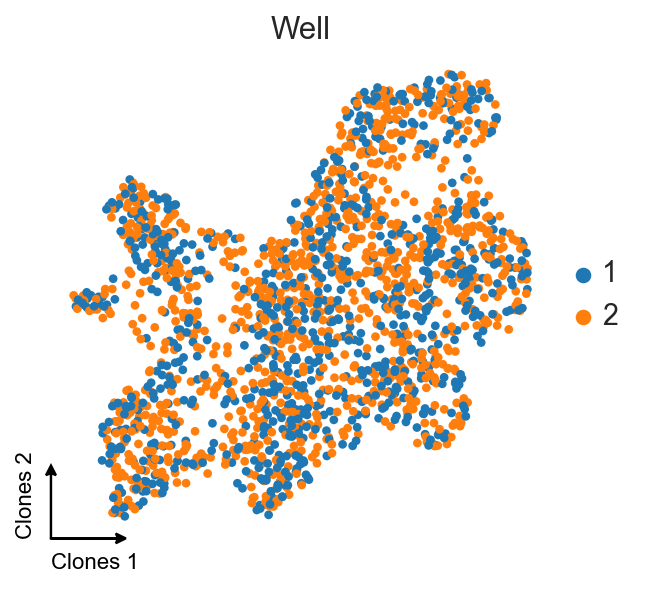

In [9]:
ax = sc.pl.umap(clones_d4, color="gex_Well", title="Well", frameon=False, show=False)
c2v.pl.embedding_axis(ax, label="Clones")

In [10]:
sc.tl.leiden(clones_d4, resolution=1, flavor="igraph", n_iterations=2)

running Leiden clustering
    finished: found 12 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


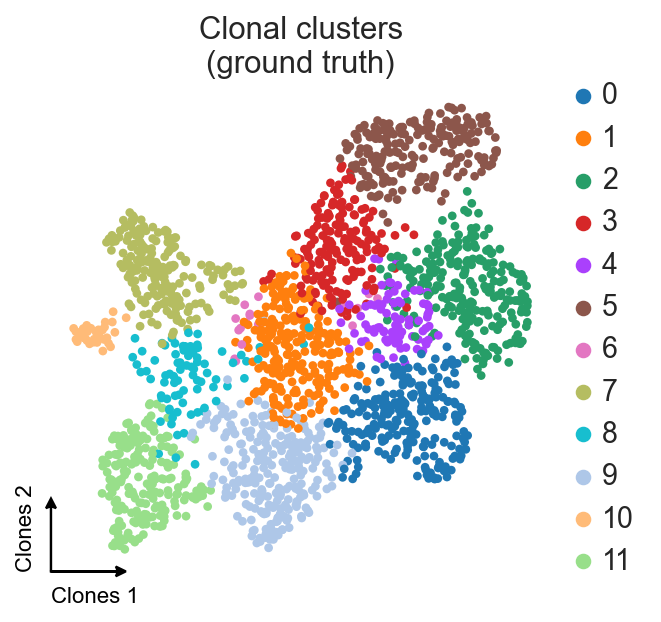

In [11]:
ax = sc.pl.umap(clones_d4, color="leiden", title="Clonal clusters\n(ground truth)",
                frameon=False, show=False)

c2v.pl.embedding_axis(ax, label="Clones")

## Building clonal embeddings using two different wells separately

Now, let's perform *de novo* integration of clonal embeddings. To do that, we firstly need to build to separate clonal embeddings.

### Well 1

In [12]:
adata_d4_w1 = adata[(adata.obs["Time point"] == 4) & (adata.obs.Well == 1)].copy()
clones_d4_w1 = c2v.pp.clones_adata(adata_d4_w1, obs_name="time:well:clone")

creating clone-level AnnData
    selected 827 clones (>= 3)
    finished (0:00:00): created clones AnnData with
     .X float matrix of proportions (clones × categories)
     .layers['proportions'] float matrix with fate proportions
     .layers['counts'] integer matrix with fate counts
     .obs['n_cells'] integer vector with number of cells per clone
     .obs['n_fates'] integer vector with number of fates per clone
     .var['n_clones'] integer vector with number of clones per fate
     .uns['fill_obs'] string label


In [13]:
c2v.tl.clonal_nn(adata_d4_w1, clones_d4_w1, use_rep="X_pca_harmony")

computing clone-to-clone adjacency graph
    finished (0:00:03): added
     .obsp['gex_adjacency'] clone adjacency graph.
     .uns['clonal_nn'] parameters.


In [14]:
c2v.tl.clone2vec(clones_d4_w1)

fitting clone2vec embeddings
    SG epochs:  23%|██▎       | 116/500 [02:10<07:11,  1.12s/it, loss=3.9988, Δ=7.96e-05]
    early stopping at epoch 117
    finished (0:02:10): added
     .obsm['clone2vec'] embedding matrix
     .uns['clone2vec'] training details


No need to create a UMAP, just `clone2vec` latent space will be enough.

Because we will use similarities of average gene expression per clone as "anchors" for the further integration, we need to obtain this information too.

In [15]:
clones_d4_w1 = c2v.pp.transfer_expression(adata_d4_w1, clones_d4_w1)

summarizing expression at clone level: 
    using `adata.X` as expression source
    finished (0:00:01): created clone-level AnnData with
     .X aggregated expression matrix (clones × genes)
     .uns['transfer_expression'] dict with 'strategy'
     .uns['mask_key'] string with obsm key for boolean mask of clones with non-zero cells
     .obsm['proportions'] dataframe of features
     .obsm['counts'] dataframe of features


In [16]:
c2v.pp.transfer_annotation(adata_d4_w1, clones_d4_w1, annotation_obs_adata="Well")

transferring annotations between cell and clone objects
    finished (0:00:00): added to clonal AnnData
     .obs['gex_Well'] categorical labels


### Well 2

And the same procedure we have to do for the second dataset.

In [17]:
adata_d4_w2 = adata[(adata.obs["Time point"] == 4) & (adata.obs.Well == 2)].copy()
clones_d4_w2 = c2v.pp.clones_adata(adata_d4_w2, obs_name="time:well:clone")

creating clone-level AnnData
    selected 1116 clones (>= 3)
    finished (0:00:00): created clones AnnData with
     .X float matrix of proportions (clones × categories)
     .layers['proportions'] float matrix with fate proportions
     .layers['counts'] integer matrix with fate counts
     .obs['n_cells'] integer vector with number of cells per clone
     .obs['n_fates'] integer vector with number of fates per clone
     .var['n_clones'] integer vector with number of clones per fate
     .uns['fill_obs'] string label


In [18]:
c2v.tl.clonal_nn(adata_d4_w2, clones_d4_w2, use_rep="X_pca_harmony")

computing clone-to-clone adjacency graph
    finished (0:00:03): added
     .obsp['gex_adjacency'] clone adjacency graph.
     .uns['clonal_nn'] parameters.


In [19]:
c2v.tl.clone2vec(clones_d4_w2)

fitting clone2vec embeddings
    SG epochs:  18%|█▊        | 89/500 [02:48<12:56,  1.89s/it, loss=4.6069, Δ=4.08e-05]
    early stopping at epoch 90
    finished (0:02:48): added
     .obsm['clone2vec'] embedding matrix
     .uns['clone2vec'] training details


In [20]:
clones_d4_w2 = c2v.pp.transfer_expression(adata_d4_w2, clones_d4_w2)

summarizing expression at clone level: 
    using `adata.X` as expression source
    finished (0:00:02): created clone-level AnnData with
     .X aggregated expression matrix (clones × genes)
     .uns['transfer_expression'] dict with 'strategy'
     .uns['mask_key'] string with obsm key for boolean mask of clones with non-zero cells
     .obsm['proportions'] dataframe of features
     .obsm['counts'] dataframe of features


In [21]:
c2v.pp.transfer_annotation(adata_d4_w2, clones_d4_w2, annotation_obs_adata="Well")

transferring annotations between cell and clone objects
    finished (0:00:00): added to clonal AnnData
     .obs['gex_Well'] categorical labels


### Integration

Basically, integration itself starts here. We need to find mutual nearest neighbors between datasets. To do that, we can use multiple approaches. The one we're suggesting here includes three steps:
1. Creation of the mean gene expression-based embedding,
2. Identification of MNNs using this embedding,
3. Integration of clones in `clone2vec` latent space using MNNs from (2).

In [22]:
clones_d4_w1w2 = sc.concat([clones_d4_w1, clones_d4_w2])
sc.pp.highly_variable_genes(clones_d4_w1w2, batch_key="gex_Well", n_top_genes=3000)

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


We're going to scale expression per each dataset individually because it removes batch effect more agressively, but there is no hard rules here.

In [23]:
# Subselection of HVGs and saving all genes
clones_d4_w1w2.raw = clones_d4_w1w2.copy()
clones_d4_w1w2 = clones_d4_w1w2[:, clones_d4_w1w2.var.highly_variable].copy()

# Densification of the .X matrix for the further scaling
clones_d4_w1w2.X = clones_d4_w1w2.X.toarray()

# Per-dataset scaling
for well in [1, 2]:
    sc.pp.scale(clones_d4_w1w2, max_value=10, mask_obs=(clones_d4_w1w2.obs.gex_Well == well).values)

After that, we're going to build PCA based on this scaled averaged per clone expression. This is the space in which we will look for mutual nearest neighbors between datasets. If this space contains too much of a batch effect, it can be additionally corrected with tools like Harmony.

In [24]:
sc.pp.pca(clones_d4_w1w2, n_comps=20)

computing PCA
    with n_comps=20
    finished (0:00:00)


In [25]:
c2v.tl.find_mnn(clones_d4_w1w2, batch_key="gex_Well", use_rep="X_pca", k_trim=1, k=5)

finding MNN anchors across batches: 
    using `clones.obsm['X_pca']` for neighbor search
    pairwise MNNs: 100%|██████████| 1/1 [00:07<00:00,  7.20s/it]
    finished (0:00:07): added
     .obsp['mnn'] symmetric sparse matrix.
     .uns['simple_mnn'] integration order and parameters.


Using identifies mutual nearest neighbors, we're going to integrate these datasets.

In [26]:
c2v.tl.align(clones_d4_w1w2)

aligning representation using weighted affine least-squares and MNN anchors
    finished (0:00:00): added
     .obsm['clone2vec_pa'] aligned representation.


Final integrated embedding is now stored at `clones.obsm["clone2vec_pa"]` slot. Let's take a look at it.

In [27]:
sc.pp.neighbors(clones_d4_w1w2, use_rep="clone2vec_pa")

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


In [28]:
sc.tl.umap(clones_d4_w1w2)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:03)


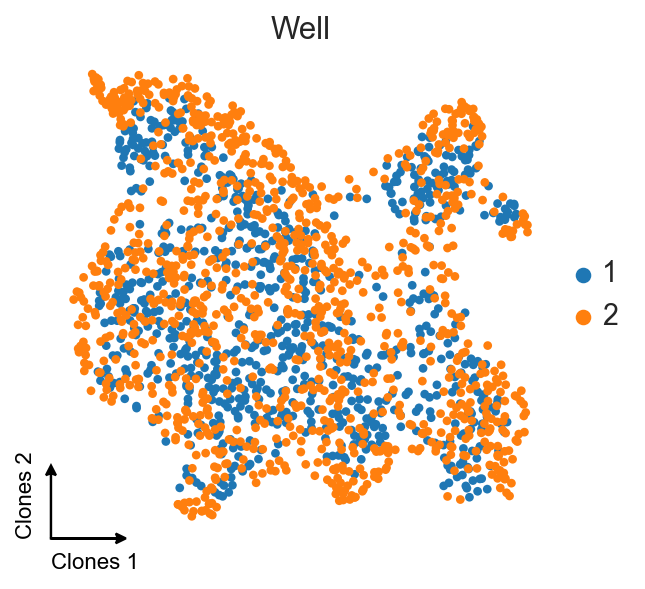

In [29]:
ax = sc.pl.umap(clones_d4_w1w2, color="gex_Well", title="Well", frameon=False, show=False)
c2v.pl.embedding_axis(ax, label="Clones")

We still see some slight batch effect between wells, but because we're already in the same clone2vec space, we can use tools like Harmony or bbknn to additionally remove batch effect. **This step isn't necessary, ans these transformations aren't linear, meaning that the resulting embedding can violate latent embedding poropeties shown in the paper**.

In [32]:
import harmonypy as hm

harmony_out = hm.run_harmony(
    data_mat=clones_d4_w1w2.obsm["clone2vec_pa"].copy(),
    meta_data=clones_d4_w1w2.obs,
    vars_use="gex_Well",
)

clones_d4_w1w2.obsm["clone2vec_pa_harmony"] = harmony_out.Z_corr

2026-05-02 14:15:13,021 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-05-02 14:15:13,022 - harmonypy - INFO -   Parameters:
2026-05-02 14:15:13,024 - harmonypy - INFO -     max_iter_harmony: 10
2026-05-02 14:15:13,025 - harmonypy - INFO -     max_iter_kmeans: 20
2026-05-02 14:15:13,027 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-05-02 14:15:13,028 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-05-02 14:15:13,030 - harmonypy - INFO -     nclust: 65
2026-05-02 14:15:13,031 - harmonypy - INFO -     block_size: 0.05
2026-05-02 14:15:13,033 - harmonypy - INFO -     lamb: [1. 1.]
2026-05-02 14:15:13,035 - harmonypy - INFO -     theta: [2. 2.]
2026-05-02 14:15:13,037 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-05-02 14:15:13,039 - harmonypy - INFO -     verbose: True
2026-05-02 14:15:13,040 - harmonypy - INFO -     random_state: 0
2026-05-02 14:15:13,042 - harmonypy - INFO -   Data: 10 PCs × 1943 cells
2026-05-02 14:15:13,043 - harmonypy - INFO 

In [33]:
sc.pp.neighbors(clones_d4_w1w2, use_rep="clone2vec_pa_harmony")

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


In [34]:
sc.tl.umap(clones_d4_w1w2)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:02)


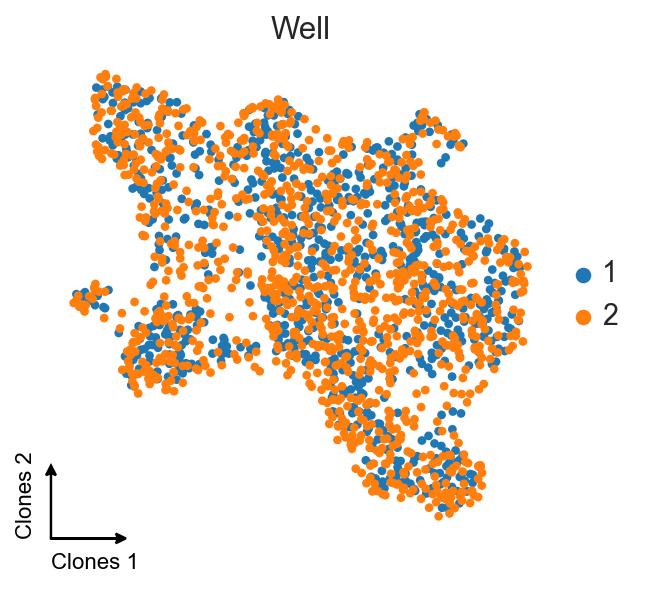

In [35]:
ax = sc.pl.umap(clones_d4_w1w2, color="gex_Well", title="Well", frameon=False, show=False)
c2v.pl.embedding_axis(ax, label="Clones")

And now we can compare this embedding with the embedding we've got at the beginning.

In [36]:
sc.tl.leiden(clones_d4_w1w2, resolution=1, flavor="igraph", n_iterations=2)

running Leiden clustering
    finished: found 12 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


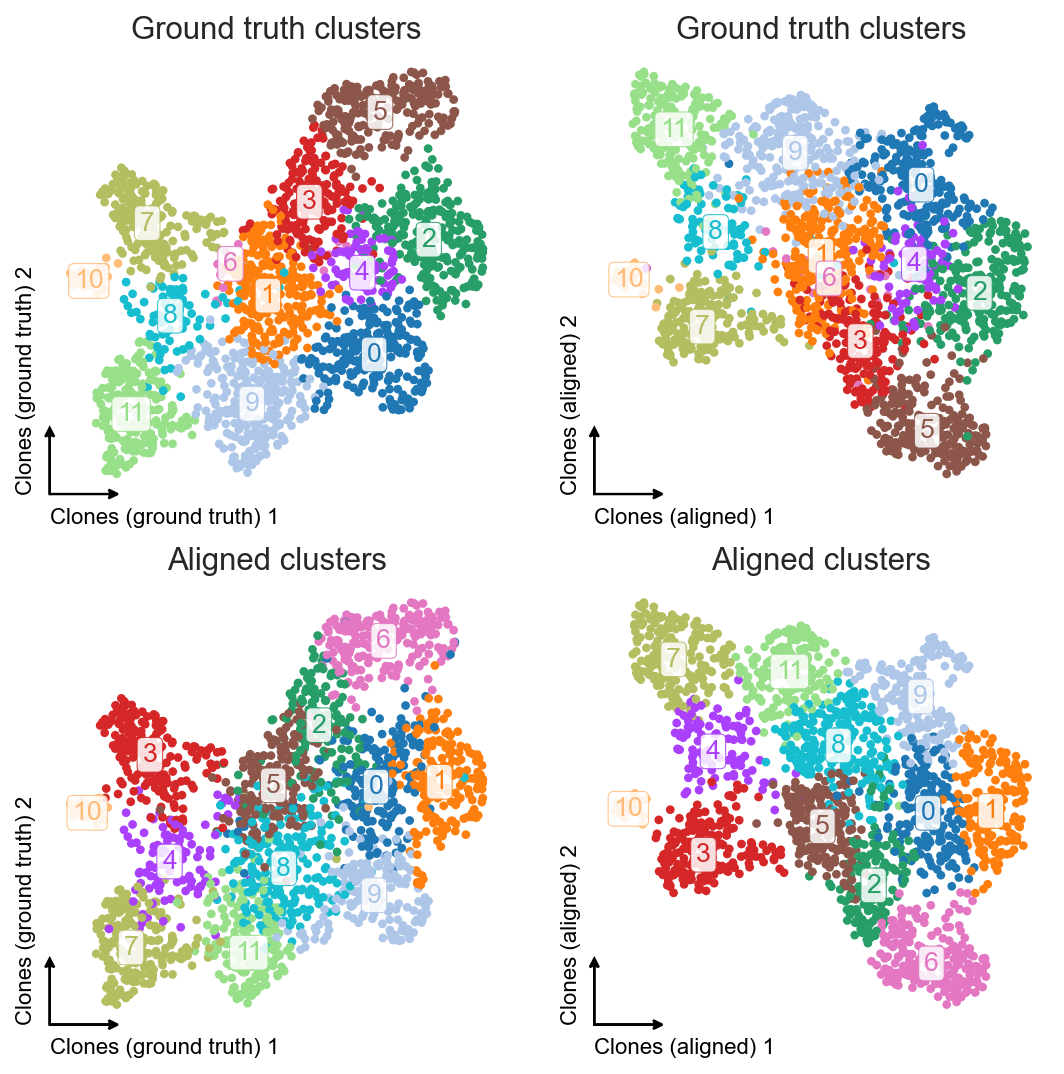

In [37]:
clones_d4.obsm["X_umap_aligned"] = clones_d4_w1w2[clones_d4.obs_names].obsm["X_umap"].copy()
clones_d4.obs["leiden_aligned"] = clones_d4_w1w2[clones_d4.obs_names].obs.leiden.copy()

fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(8, 8))

sc.pl.embedding(
    clones_d4,
    ax=axes[0, 0],
    show=False,
    basis="X_umap",
    frameon=False,
    color="leiden",
    title="Ground truth clusters",
)
c2v.pl.fancy_legend(axes[0, 0], center_loc=True, textsize=12)
c2v.pl.embedding_axis(axes[0, 0], label="Clones (ground truth)")

sc.pl.embedding(
    clones_d4,
    ax=axes[0, 1],
    show=False,
    basis="X_umap_aligned",
    frameon=False,
    color="leiden",
    title="Ground truth clusters",
)
c2v.pl.fancy_legend(axes[0, 1], center_loc=True, textsize=12)
c2v.pl.embedding_axis(axes[0, 1], label="Clones (aligned)")

sc.pl.embedding(
    clones_d4,
    ax=axes[1, 0],
    show=False,
    basis="X_umap",
    frameon=False,
    color="leiden_aligned",
    title="Aligned clusters",
)
c2v.pl.fancy_legend(axes[1, 0], center_loc=True, textsize=12)
c2v.pl.embedding_axis(axes[1, 0], label="Clones (ground truth)")

sc.pl.embedding(
    clones_d4,
    ax=axes[1, 1],
    show=False,
    basis="X_umap_aligned",
    frameon=False,
    color="leiden_aligned",
    title="Aligned clusters",
)
c2v.pl.fancy_legend(axes[1, 1], center_loc=True, textsize=12)
c2v.pl.embedding_axis(axes[1, 1], label="Clones (aligned)")

We can vertically flip the second UMAP to make it visually more comparable to the left one.

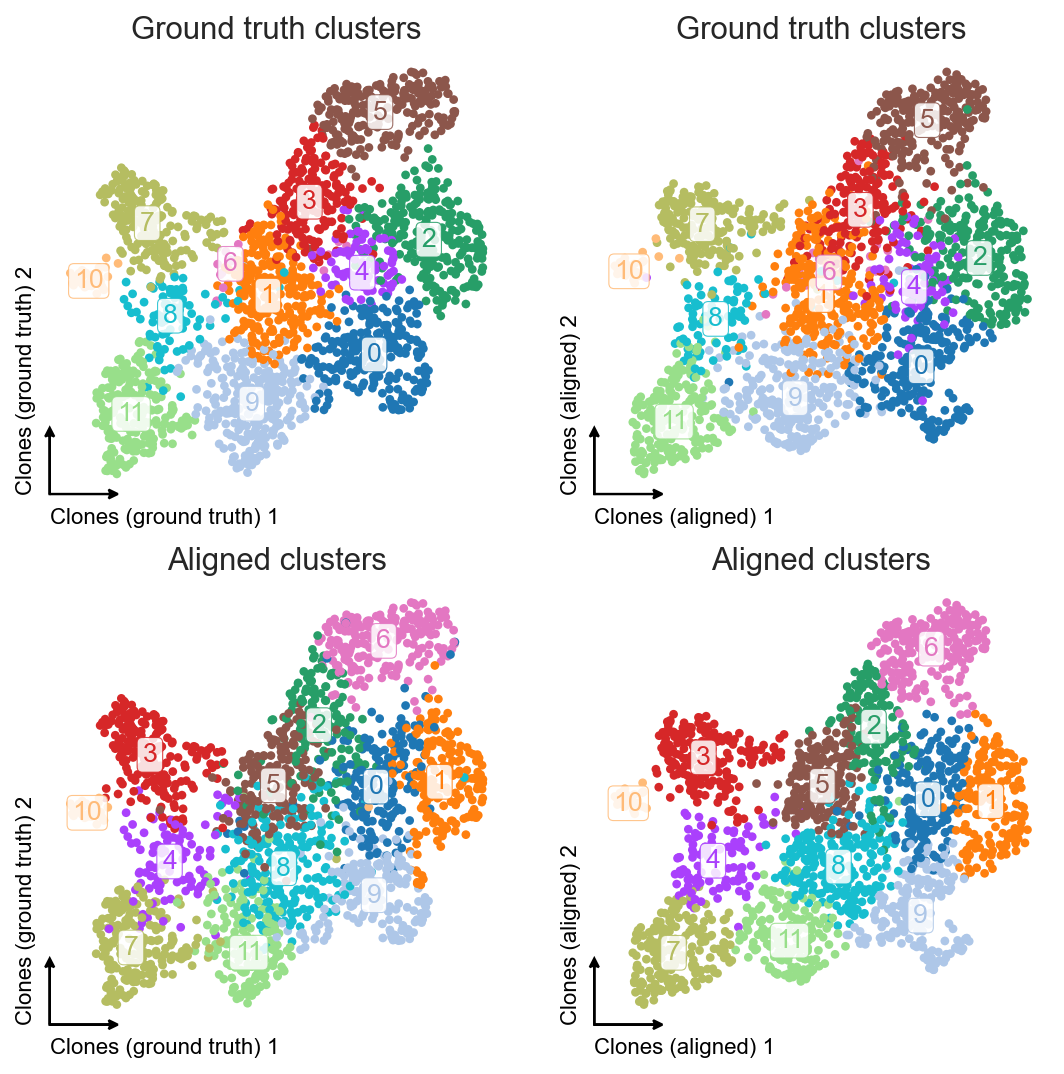

In [39]:
clones_d4.obsm["X_umap_aligned"][:, 1] = -clones_d4.obsm["X_umap_aligned"][:, 1]

fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(8, 8))

sc.pl.embedding(
    clones_d4,
    ax=axes[0, 0],
    show=False,
    basis="X_umap",
    frameon=False,
    color="leiden",
    title="Ground truth clusters",
)
c2v.pl.fancy_legend(axes[0, 0], center_loc=True, textsize=12)
c2v.pl.embedding_axis(axes[0, 0], label="Clones (ground truth)")

sc.pl.embedding(
    clones_d4,
    ax=axes[0, 1],
    show=False,
    basis="X_umap_aligned",
    frameon=False,
    color="leiden",
    title="Ground truth clusters",
)
c2v.pl.fancy_legend(axes[0, 1], center_loc=True, textsize=12)
c2v.pl.embedding_axis(axes[0, 1], label="Clones (aligned)")

sc.pl.embedding(
    clones_d4,
    ax=axes[1, 0],
    show=False,
    basis="X_umap",
    frameon=False,
    color="leiden_aligned",
    title="Aligned clusters",
)
c2v.pl.fancy_legend(axes[1, 0], center_loc=True, textsize=12)
c2v.pl.embedding_axis(axes[1, 0], label="Clones (ground truth)")

sc.pl.embedding(
    clones_d4,
    ax=axes[1, 1],
    show=False,
    basis="X_umap_aligned",
    frameon=False,
    color="leiden_aligned",
    title="Aligned clusters",
)
c2v.pl.fancy_legend(axes[1, 1], center_loc=True, textsize=12)
c2v.pl.embedding_axis(axes[1, 1], label="Clones (aligned)")

We see that the resulting embeddings are very similar, and for the second one we didn't have to create an integrated gene expression embedding.